In [1]:
# Setup and Tokenization
import os
import sys
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm.notebook import tqdm

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.config import RAW_MAESTRO_DIR, CHECKPOINTS_DIR, GENERATED_MIDIS_DIR, PLOTS_DIR, BATCH_SIZE
from src.preprocessing.tokenizer import get_tokenizer
from src.models.transformer import MusicTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training Transformer on device: {device}")

tokenizer = get_tokenizer()
vocab_size = len(tokenizer)
print(f"REMI Tokenizer Vocabulary Size: {vocab_size}")

# 1. Load Metadata and filter
metadata_path = RAW_MAESTRO_DIR / "maestro-v3.0.0.csv"
df = pd.read_csv(metadata_path)
genre_mapping = {
    "Johann Sebastian Bach": "Baroque", "Wolfgang Amadeus Mozart": "Classical",
    "Frédéric Chopin": "Romantic", "Claude Debussy": "Impressionist_Modern"
}
df['proxy_genre'] = df['canonical_composer'].map(genre_mapping)
df_filtered = df.dropna(subset=['proxy_genre']).copy()

# Limit to 50 files for feasible notebook execution (expand later!)
df_subset = df_filtered.sample(n=50, random_state=42)

# 2. Tokenize the MIDI files
all_tokens = []
print("Tokenizing MIDI files into discrete REMI tokens...")
for _, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
    midi_path = RAW_MAESTRO_DIR / row['midi_filename']
    if midi_path.exists():
        try:
            tokens = tokenizer(midi_path)
            # MidiTok returns TokSequence objects. Convert to list of integers
            if hasattr(tokens, 'ids'):
                # TokSequence has an ids attribute
                all_tokens.extend(tokens.ids)
            elif isinstance(tokens, list):
                if len(tokens) > 0 and hasattr(tokens[0], 'ids'):
                    # List of TokSequence objects (multi-track)
                    for tok_seq in tokens:
                        all_tokens.extend(tok_seq.ids)
                else:
                    # Already integers or other numeric types
                    all_tokens.extend(tokens)
            else:
                # Try to iterate and convert
                all_tokens.extend(list(tokens))
        except Exception as e:
            continue

# Convert to a single giant 1D PyTorch tensor
all_tokens = torch.tensor(all_tokens, dtype=torch.long)
print(f"Total tokens extracted: {len(all_tokens):,}")

mkdir -p failed for path C:\Users\User\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\User\\.matplotlib'
Matplotlib created a temporary cache directory at C:\Users\User\AppData\Local\Temp\matplotlib-0kgzcwsg because there was an issue with the default path (C:\Users\User\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Training Transformer on device: cuda
REMI Tokenizer Vocabulary Size: 280
Tokenizing MIDI files into discrete REMI tokens...


  0%|          | 0/50 [00:00<?, ?it/s]

Total tokens extracted: 645,881


In [3]:
# Transformer Dataset & DataLoader
SEQ_LEN = 256  # The context window of our Transformer

class TokenDataset(Dataset):
    """Chunks the massive 1D token tensor into sequences of SEQ_LEN."""
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len
        
    def __len__(self):
        return (len(self.data) - 1) // self.seq_len
        
    def __getitem__(self, idx):
        i = idx * self.seq_len
        x = self.data[i : i + self.seq_len]
        # Target y is shifted by exactly 1 token into the future
        y = self.data[i + 1 : i + self.seq_len + 1]
        return x, y

# Simple 80/20 train-val split
split_idx = int(len(all_tokens) * 0.8)
train_data, val_data = all_tokens[:split_idx], all_tokens[split_idx:]

train_loader = DataLoader(TokenDataset(train_data, SEQ_LEN), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(TokenDataset(val_data, SEQ_LEN), batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Prepared {len(train_loader)} training batches.")

Prepared 31 training batches.


Starting Transformer Training...
Epoch [1/15] | Train PPL: 55.64 | Val PPL: 26.47
Epoch [2/15] | Train PPL: 22.91 | Val PPL: 21.56
Epoch [3/15] | Train PPL: 20.28 | Val PPL: 20.16
Epoch [4/15] | Train PPL: 19.01 | Val PPL: 19.12
Epoch [5/15] | Train PPL: 17.93 | Val PPL: 18.14
Epoch [6/15] | Train PPL: 17.20 | Val PPL: 17.62
Epoch [7/15] | Train PPL: 16.64 | Val PPL: 17.18
Epoch [8/15] | Train PPL: 16.12 | Val PPL: 16.77
Epoch [9/15] | Train PPL: 15.73 | Val PPL: 16.52
Epoch [10/15] | Train PPL: 15.45 | Val PPL: 16.25
Epoch [11/15] | Train PPL: 15.24 | Val PPL: 16.18
Epoch [12/15] | Train PPL: 15.04 | Val PPL: 15.98
Epoch [13/15] | Train PPL: 14.87 | Val PPL: 15.86
Epoch [14/15] | Train PPL: 14.70 | Val PPL: 15.74
Epoch [15/15] | Train PPL: 14.57 | Val PPL: 15.65


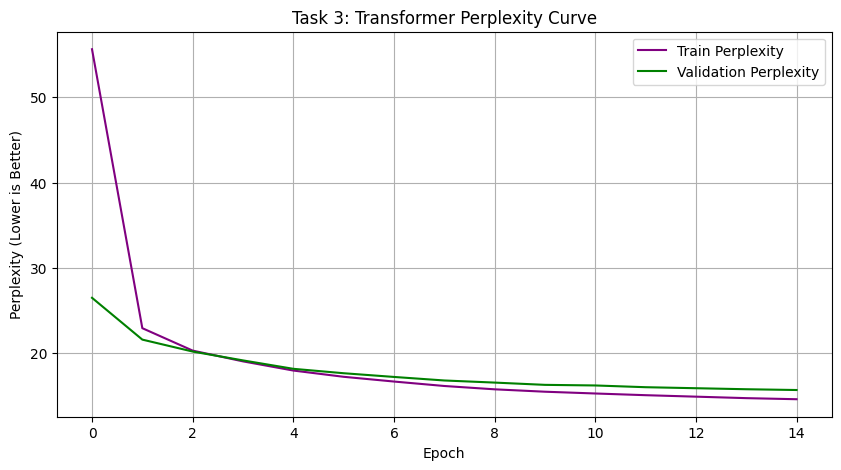

In [4]:
# Training Loop and Perplexity Tracking
model = MusicTransformer(vocab_size=vocab_size, d_model=256, nhead=8, num_layers=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

epochs = 15
history = {'train_ppl': [], 'val_ppl': []}

print("Starting Transformer Training...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        logits = model(x) # Shape: (batch, seq_len, vocab_size)
        
        # Flatten for CrossEntropy: (batch * seq_len, vocab_size)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))
        
        loss.backward()
        # Crucial to prevent exploding gradients in Transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        
    # Calculate Perplexity = exp(loss)
    avg_train_loss = total_loss / len(train_loader)
    train_ppl = math.exp(avg_train_loss)
    history['train_ppl'].append(train_ppl)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_ppl = math.exp(avg_val_loss)
    history['val_ppl'].append(val_ppl)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f}")

torch.save(model.state_dict(), CHECKPOINTS_DIR / "task3_transformer.pth")

# Plot Perplexity
plt.figure(figsize=(10, 5))
plt.plot(history['train_ppl'], label='Train Perplexity', color='purple')
plt.plot(history['val_ppl'], label='Validation Perplexity', color='green')
plt.title('Task 3: Transformer Perplexity Curve')
plt.xlabel('Epoch')
plt.ylabel('Perplexity (Lower is Better)')
plt.legend()
plt.grid(True)
plt.savefig(PLOTS_DIR / "task3_perplexity_curve.png")
plt.show()

In [12]:
# Cell 4: Top-K & Temperature Generation (FINAL UPDATE)
from miditok import TokSequence

def generate_music(model, tokenizer, start_tokens, max_len=1024, temperature=0.9, top_k=15):
    """Autoregressively generates a long sequence of tokens."""
    model.eval()
    tokens = start_tokens.tolist()
    
    with torch.no_grad():
        for _ in tqdm(range(max_len), leave=False, desc="Generating"):
            x = torch.tensor([tokens[-SEQ_LEN:]]).to(device) 
            logits = model(x)
            
            next_token_logits = logits[0, -1, :] / temperature
            top_k_logits, top_k_indices = torch.topk(next_token_logits, top_k)
            probs = F.softmax(top_k_logits, dim=-1)
            
            next_token_idx = torch.multinomial(probs, num_samples=1)
            next_token = top_k_indices[next_token_idx].item()
            tokens.append(next_token)
            
    return tokens

print("Generating 10 Multi-Minute Compositions (1024 tokens each)...")
start_seed = torch.tensor([1]) 

for i in range(10):
    try:
        generated_tokens = generate_music(model, tokenizer, start_seed, max_len=1024, temperature=0.95, top_k=15)
        
        seq = TokSequence(ids=generated_tokens)
        generated_midi = tokenizer([seq]) 
        
        out_path = GENERATED_MIDIS_DIR / f"task3_transformer_sample_{i+1}.mid"
        
        # --- THE FIX ---
        # The symusic backend requires .dump_midi() instead of .dump()
        generated_midi.dump_midi(str(out_path))
        # ---------------
        
        print(f"Saved: {out_path}")
    except Exception as e:
        print(f"Failed to generate sample {i+1}: {e}")

print("Task 3 Transformer Generation Complete!")

Generating 10 Multi-Minute Compositions (1024 tokens each)...


Generating:   0%|          | 0/1024 [00:00<?, ?it/s]

Saved: Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task3_transformer_sample_1.mid


Generating:   0%|          | 0/1024 [00:00<?, ?it/s]

Saved: Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task3_transformer_sample_2.mid


...

Saved: Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task3_transformer_sample_8.mid


Generating:   0%|          | 0/1024 [00:00<?, ?it/s]

Saved: Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task3_transformer_sample_9.mid


Generating:   0%|          | 0/1024 [00:00<?, ?it/s]

Saved: Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task3_transformer_sample_10.mid
Task 3 Transformer Generation Complete!
